In [1]:
import numpy as np
import matplotlib.pyplot as plt
from control import *
import sys
sys.path.append('../..')
from simulation.model.motor_params import *

In [2]:
# State space matrices
# States: x = [i, omega, theta]

A = np.array([[-R_mot/L_mot,    -Ke_mot/L_mot,  0],
              [ Kt_mot/J_mot,  -B_mot/J_mot, 0],
              [ 0,       1,      0]])

B = np.array([[1/L_mot],
               [0  ],
               [0  ]])

C = np.array([[0, 0, 1]])  # measure theta only
D = np.array([[0]])

motor_ss = ss(A, B, C, D)
print(motor_ss)

<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[-4.e+03 -2.e+02  0.e+00]
     [ 1.e+01 -1.e-01  0.e+00]
     [ 0.e+00  1.e+00  0.e+00]]

B = [[2000.]
     [   0.]
     [   0.]]

C = [[0. 0. 1.]]

D = [[0.]]


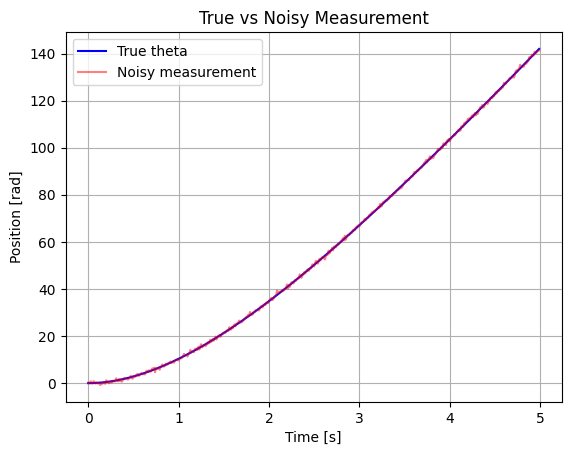

In [3]:
# Simulation parameters
dt = 0.01 # time step [s]
t = np.arange(0, 5, dt)
u = np.ones_like(t) * 5.0 # step input - 5V

# True ystem response
t_out, y_true = forced_response(motor_ss, T=t, U=u)

# Add measurement noise to simulate encoder
np.random.seed(42)
noise_std = 0.5 # encoder noise [rad]
y_noisy = y_true + np.random.normal(0, noise_std, len(t))

plt.plot(t, y_true, 'b', label='True theta')
plt.plot(t, y_noisy, 'r', alpha=0.5, label='Noisy measurement')
plt.xlabel('Time [s]')
plt.ylabel('Position [rad]')
plt.title('True vs Noisy Measurement')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Kalman Filter implementation
# Discrete time model
from scipy.linalg import expm, solve_discrete_are

# Discretize system
A_d = expm(A * dt)
B_d = B * dt

# Noise covariance matrices
Q_kal = np.diag([0.01, 0.01, 0.01]) # process disturbance
R_kal = np.array([[noise_std**2]])  # measurement noise

# Kalman gain (steady state)
P = solve_discrete_are(A_d.T, C.T, Q_kal, R_kal)
K_kal = P @ C.T @ np.linalg.inv(C @ P @ C.T + R_kal)
print(f'Kalman gain: {K_kal.T}')

Kalman gain: [[-0.00496375  0.0992601   0.18543054]]
